In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from urllib.request import urlretrieve

from scipy import stats 
from scipy.signal import find_peaks
import os
from scipy.stats import expon, weibull_min, gumbel_r, genpareto

In [ ]:
wave_data = pd.read_csv('WaveP2.csv')
wave_data['valid_time'] = pd.to_datetime(wave_data['valid_time'])
wave_data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'WaveP2.csv'

Text(0, 0.5, 'Significant Wave Height (m)')

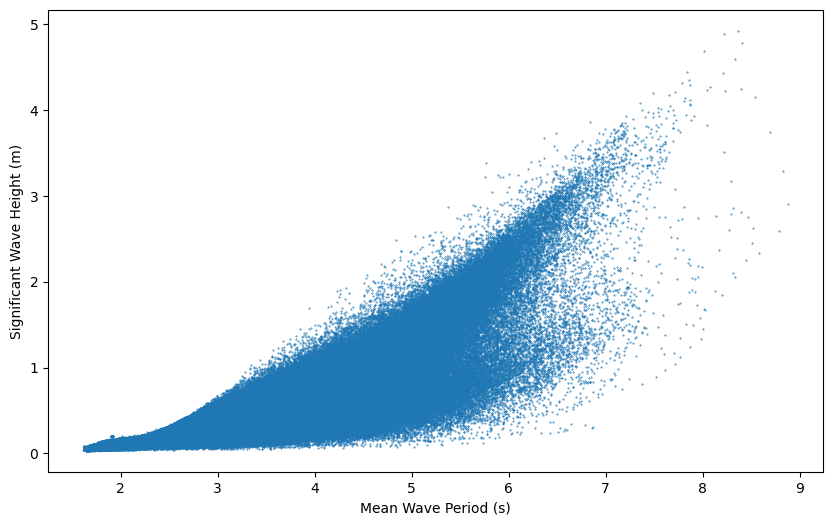

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(wave_data['mwp'], wave_data['swh'], 'o', markersize=0.4, label='Data Points')
plt.xlabel('Mean Wave Period (s)')
plt.ylabel('Significant Wave Height (m)')

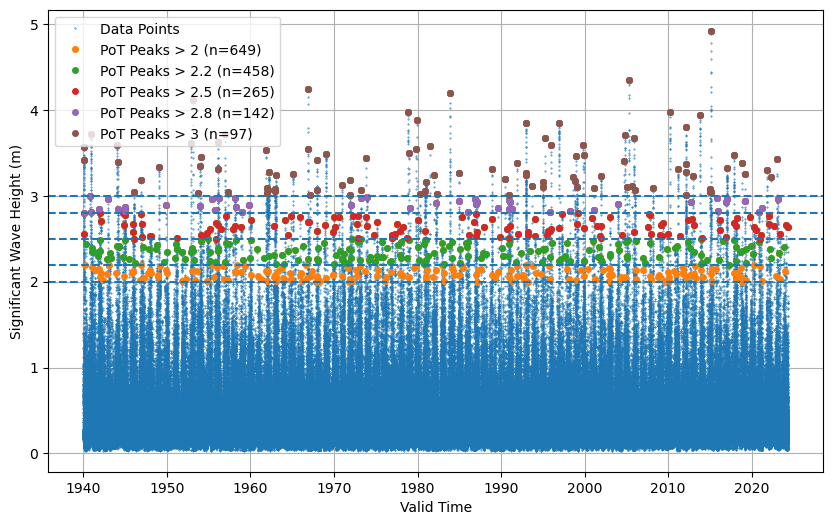

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(wave_data['valid_time'], wave_data['swh'], 'o', markersize=0.4, label='Data Points')

thresholds = [2, 2.2, 2.5, 2.8, 3]

for i in range(len(thresholds)):
    # Find independent peaks over threshold
    peaks, _ = find_peaks(wave_data['swh'], height=thresholds[i], Distance=48)
    
    # Count peaks (PoT events)
    num_peaks = len(peaks)
    
    # Plot peaks
    plt.plot(wave_data['valid_time'].iloc[peaks],
             wave_data['swh'].iloc[peaks],
             '.', markersize=8,
             label=f'PoT Peaks > {thresholds[i]} (n={num_peaks})')
    
    # Plot threshold line
    plt.axhline(y=thresholds[i], linestyle='--')

plt.xlabel('Valid Time')
plt.ylabel('Significant Wave Height (m)')
plt.legend()
plt.grid()

In [ ]:
peaks, _ = find_peaks(wave_data['swh'], height=2.2, Distance=48)
# Filter to only include peaks above the threshold in the dataset
wave_data_filtered = wave_data.iloc[peaks]

# second filter to only include peaks with mean wave direction between 0 and 100 degrees
wave_data_filtered = wave_data_filtered[(wave_data_filtered['mwd'] >= 0) & (wave_data_filtered['mwd'] <= 100)]
wave_data_filtered.head()

,valid_time,mwd,mwp,swh,latitude,longitude
242,1940-01-11 02:00:00,61.60254,7.409813,3.563955,44.5,12.5
427,1940-01-18 19:00:00,41.57454,6.400721,2.801368,44.5,12.5
560,1940-01-24 08:00:00,61.36197,7.470216,3.417040,44.5,12.5
1043,1940-02-13 11:00:00,52.68761,6.254020,2.560599,44.5,12.5
2328,1940-04-07 00:00:00,43.19943,5.928788,2.438833,44.5,12.5


Average Mean Wave Direction: 52.75°


Text(0, 0.5, 'Significant Wave Height (m)')

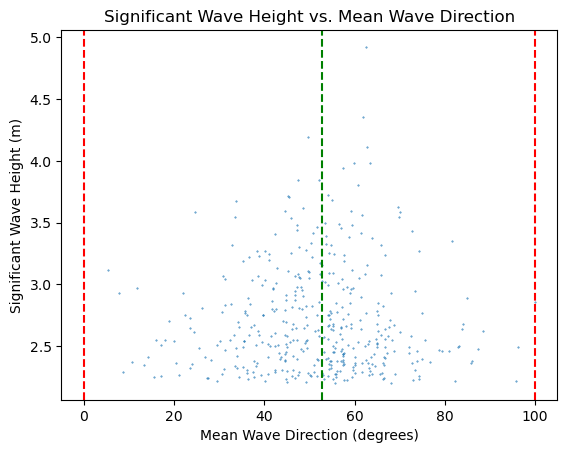

In [ ]:
plt.plot(wave_data_filtered['mwd'], wave_data_filtered['swh'], 'o', markersize=0.4, label='Data Points')
average_direction = wave_data_filtered['mwd'].median()
print(f"Average Mean Wave Direction: {average_direction:.2f}°")
plt.axvline(x=average_direction, color='g', linestyle='--', label=f'Average Direction: {average_direction:.2f}°')
plt.axvline(x=0, color='r', linestyle='--', label='Average Direction: 0°')
plt.axvline(x=100, color='r', linestyle='--', label='Average Direction: 100°')
plt.title('Significant Wave Height vs. Mean Wave Direction')
plt.xlabel('Mean Wave Direction (degrees)')
plt.ylabel('Significant Wave Height (m)')

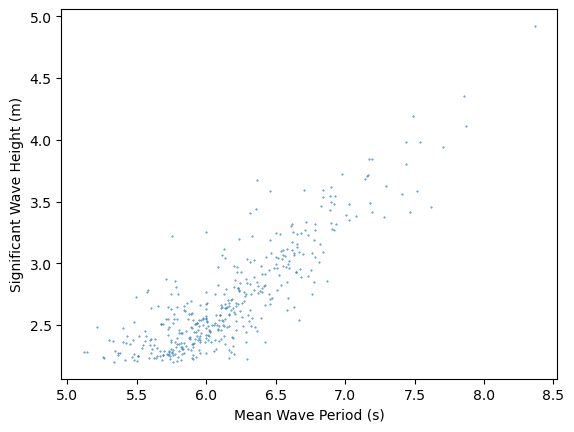

In [ ]:
plt.plot(wave_data_filtered['mwp'], wave_data_filtered['swh'], 'o', markersize=0.4, label='Data Points')
plt.xlabel('Mean Wave Period (s)')
plt.ylabel('Significant Wave Height (m)');

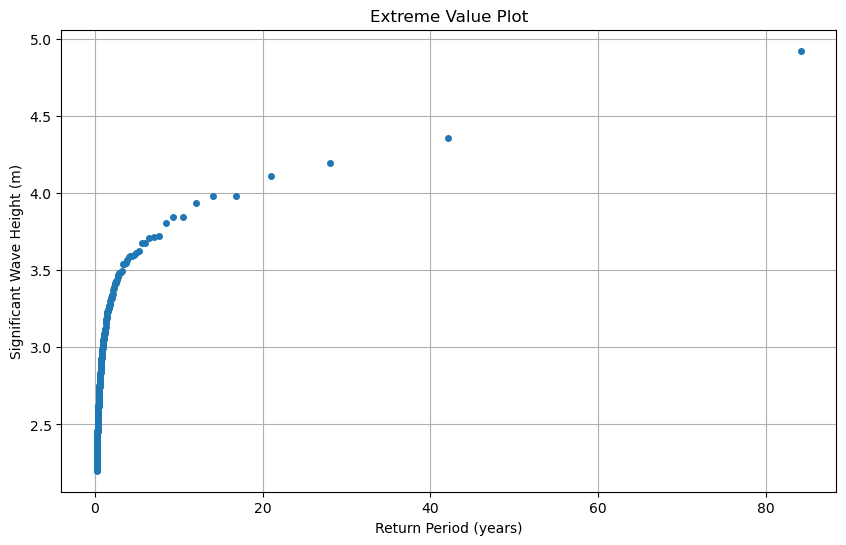

In [ ]:
waveheights = wave_data_filtered['swh'].to_numpy()
sorted_waveheights = np.sort(waveheights)

N = len(sorted_waveheights)
i = np.arange(1, N + 1)

# Compute probabilities
P = i / (N + 1)      # non-exceedance probability
Q = 1 - P            # exceedance probability (used in your slide)
Ns = N / 84          # number of peaks per year (assuming 84 peaks in the dataset)   
R = 1 / (Q * Ns)     # return period in years

plt.figure(figsize=(10, 6))
plt.plot(R, sorted_waveheights, 'o', markersize=4)

plt.xlabel('Return Period (years)')
plt.ylabel('Significant Wave Height (m)')
plt.title('Extreme Value Plot')

plt.grid()

In [ ]:
def RMSE(observed, predicted):
    return np.sqrt(np.mean((observed - predicted) ** 2))

Exponential RMSE: 0.0837
Weibull RMSE: 0.0267
Gumbel RMSE: 0.0813
GPD RMSE: 0.0280


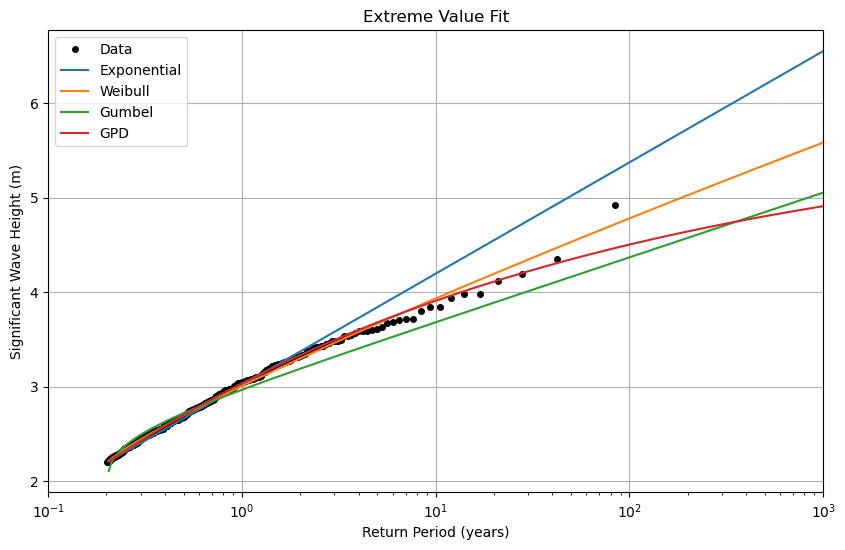

In [ ]:
# Data
x = wave_data_filtered['swh'].dropna().to_numpy()
x_sorted = np.sort(x)

# Smooth return period axis for fitted curves
R_fit = np.logspace(np.log10(0.1), np.log10(1000), 500)
Q_fit = 1 / (R_fit * Ns)
P_fit = 1 - Q_fit
# -------------------------
# Fit distributions
# -------------------------

# Exponential
loc_exp, scale_exp = expon.fit(x)

# Weibull
shape_w, loc_w, scale_w = weibull_min.fit(x)

# Gumbel
loc_g, scale_g = gumbel_r.fit(x)

# GPD over threshold
threshold = 2.2   # choose your PoT threshold
excess = x[x > threshold] - threshold
shape_gpd, loc_gpd, scale_gpd = genpareto.fit(excess, floc=0)

# -------------------------
# Return level curves
# -------------------------

z_exp = expon.ppf(P_fit, loc=loc_exp, scale=scale_exp)
z_weibull = weibull_min.ppf(P_fit, shape_w, loc=loc_w, scale=scale_w)
z_gumbel = gumbel_r.ppf(P_fit, loc=loc_g, scale=scale_g)

# For GPD, use exceedance rate above threshold
Nu = len(excess) / years
Q_gpd = 1 / (R_fit * Nu)
P_gpd = 1 - Q_gpd
z_gpd = threshold + genpareto.ppf(P_gpd, shape_gpd, loc=0, scale=scale_gpd)

# -------------------------
# calculate error
# -------------------------

# Exponential
z_exp_at_data = expon.ppf(P, loc=loc_exp, scale=scale_exp)
rmse_exp = RMSE(x_sorted, z_exp_at_data)
print(f'Exponential RMSE: {rmse_exp:.4f}')

# Weibull
z_weibull_at_data = weibull_min.ppf(P, shape_w, loc=loc_w, scale=scale_w)
rmse_weibull = RMSE(x_sorted, z_weibull_at_data)
print(f'Weibull RMSE: {rmse_weibull:.4f}')

# Gumbel
z_gumbel_at_data = gumbel_r.ppf(P, loc=loc_g, scale=scale_g)
rmse_gumbel = RMSE(x_sorted, z_gumbel_at_data)
print(f'Gumbel RMSE: {rmse_gumbel:.4f}')

# GPD
z_gpd_at_data = threshold + genpareto.ppf(P, shape_gpd, loc=0, scale=scale_gpd)
rmse_gpd = RMSE(x_sorted, z_gpd_at_data)
print(f'GPD RMSE: {rmse_gpd:.4f}')
# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(10, 6))

plt.plot(R, x_sorted, 'ko', markersize=4, label='Data')
plt.plot(R_fit, z_exp, label='Exponential')
plt.plot(R_fit, z_weibull, label='Weibull')
plt.plot(R_fit, z_gumbel, label='Gumbel')
plt.plot(R_fit, z_gpd, label='GPD')

plt.xlabel('Return Period (years)')
plt.xscale('log')
plt.xlim(0.1, 1000)
plt.ylabel('Significant Wave Height (m)')
plt.title('Extreme Value Fit')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# return_period_list = [1, 10, 50, 100, 500, 1000]  In pinciple not nessary, still can be helpful to see different fits
# for T in return_period_list:
#     Q_T = 1 / (T * Ns)
#     P_T = 1 - Q_T
#     z_exp_T = expon.ppf(P_T, loc=loc_exp, scale=scale_exp)
#     z_weibull_T = weibull_min.ppf(P_T, shape_w, loc=loc_w, scale=scale_w)
#     z_gumbel_T = gumbel_r.ppf(P_T, loc=loc_g, scale=scale_g)
#     z_gpd_T = threshold + genpareto.ppf(P_T, shape_gpd, loc=0, scale=scale_gpd)
    
#     print(f'Return Period: {T} years')
#     print(f'  Exponential: {z_exp_T:.2f} m')
#     print(f'  Weibull: {z_weibull_T:.2f} m')
#     print(f'  Gumbel: {z_gumbel_T:.2f} m')
#     print(f'  GPD: {z_gpd_T:.2f} m\n')

In [ ]:
return_period_list = [1, 10, 50, 100, 500, 1000]
Q_T = 1 / (np.array(return_period_list) * Ns)
P_T = 1 - Q_T

z_weibull_T = weibull_min.ppf(P_T, shape_w, loc=loc_w, scale=scale_w)
print("Weibull Return Levels:")
for T, z, Q_T_ in zip(return_period_list, z_weibull_T, Q_T):
    print(f"{T}-year return level: {z:.2f} m, with exceedence propability {Q_T_:.4f}")

Weibull Return Levels:
1-year return level: 3.01 m, with exceedence propability 0.2019
10-year return level: 3.93 m, with exceedence propability 0.0202
50-year return level: 4.53 m, with exceedence propability 0.0040
100-year return level: 4.78 m, with exceedence propability 0.0020
500-year return level: 5.35 m, with exceedence propability 0.0004
1000-year return level: 5.58 m, with exceedence propability 0.0002


In [ ]:
# # Data
# x = wave_data_filtered['swh'].to_numpy()   # input (wave height)
# y = wave_data_filtered['mwp'].to_numpy()   # output (period)

# # Remove invalid values (log needs >0)
# mask = (x > 0) & (y > 0)
# x = x[mask]
# y = y[mask]

# # Log transform
# log_x = np.log(x)
# log_y = np.log(y)

# # Fit
# d, log_c = np.polyfit(log_x, log_y, 1)
# c = np.exp(log_c)

# print(f'Power law: mwp = {c:.3f} * swh^{d:.3f}')

# x_fit = np.linspace(x.min(), x.max(), 100)
# y_fit = c * x_fit**d

# plt.figure(figsize=(10, 6))
# plt.plot(x, y, 'o', markersize=0.4, label='Data')
# plt.plot(x_fit, y_fit, 'r-', linewidth=2,
#          label=f'mwp = {c:.2f} * swh^{d:.2f}')

# plt.xlabel('Significant Wave Height (m)')
# plt.ylabel('Mean Wave Period (s)')
# plt.legend()
# plt.grid()

# def predict_mwp_from_swh_power(swh_values, c, d):
#     swh_values = np.array(swh_values)
#     return c * swh_values**d

# # Example
# wave_heights = [2.5, 3.0, 3.5, 4.0]
# predicted_periods = predict_mwp_from_swh_power(wave_heights, c, d)

# for h, p in zip(wave_heights, predicted_periods):
#     print(f"SWH = {h:.2f} m → MWP ≈ {p:.2f} s")

Equation: Tp = 3.93 * Hs^0.45
Predicted Tp for Hs=3.007: 6.49s
Predicted Tp for Hs=3.934: 7.33s
Predicted Tp for Hs=4.531: 7.81s
Predicted Tp for Hs=4.781: 8.00s
Predicted Tp for Hs=5.345: 8.42s
Predicted Tp for Hs=5.583: 8.59s


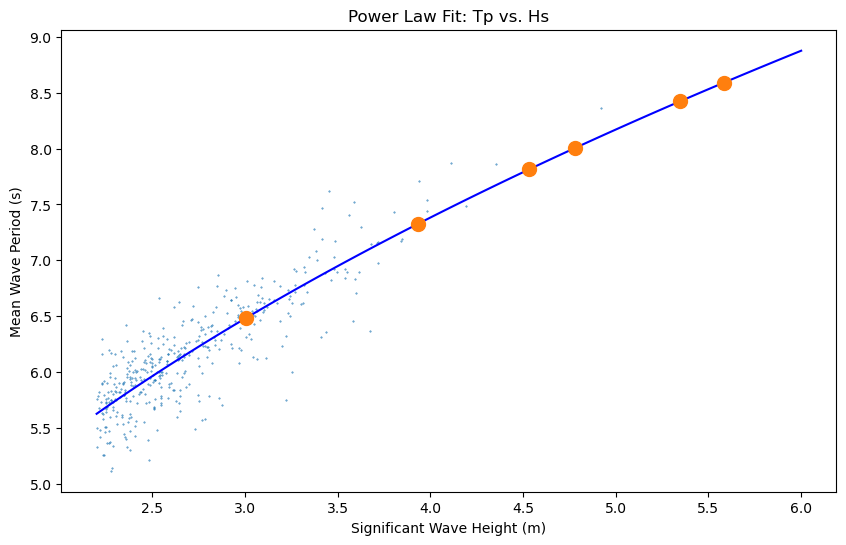

In [ ]:
# 1. Define the power law function
def power_law(x, a, b):
    return a * np.power(x, b)
 
# 2. Your data 
hs_data = wave_data_filtered['swh'].to_numpy()   # input (wave height)
tp_data = wave_data_filtered['mwp'].to_numpy()   # output (period)


# 3. Fit the curve
# popt contains the optimized parameters [a, b]
popt, pcov = curve_fit(power_law, hs_data, tp_data)
 
a_fit, b_fit = popt
print(f"Equation: Tp = {a_fit:.2f} * Hs^{b_fit:.2f}")
 
# 4. Predict Tp for an extreme Hs (e.g., a 100-year return value of 9.5m)
hs_extreme = z_weibull_T
tp_predicted = power_law(hs_extreme, *popt)
for h, p in zip(hs_extreme, tp_predicted):
    print(f"Predicted Tp for Hs={h:.3f}: {p:.2f}s")

x_spacing = np.linspace(hs_data.min(), 6, 100)
y_fit = power_law(x_spacing, *popt)
plt.figure(figsize=(10, 6))

plt.plot(hs_data, tp_data, 'o', markersize=0.4, label='Data')
plt.plot(x_spacing, y_fit, 'b-', label='Fitted Power Law')
plt.plot(hs_extreme, tp_predicted, 'o', markersize=10, label='Predicted Tp for Extreme Hs')
plt.xlabel('Significant Wave Height (m)')
plt.ylabel('Mean Wave Period (s)')
plt.title('Power Law Fit: Tp vs. Hs');

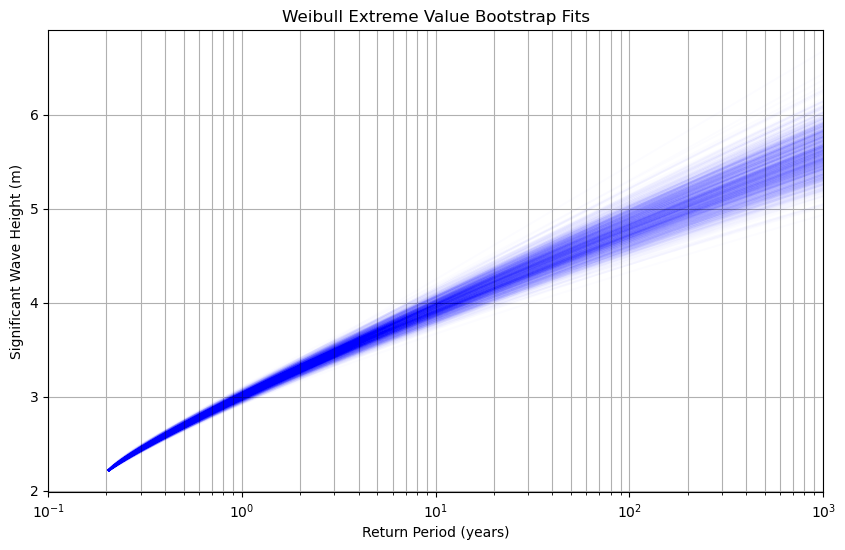

In [ ]:
number_of_bootstraps = 1000

RMSE_values = []
bootstrap_curves = []
bootstrap_curves = []

plt.figure(figsize=(10, 6))

# Basic calculations
N = len(x_sorted)
rank = np.arange(1, N + 1)

P = rank / (N + 1)
Q = 1 - P

Ns = N / years
R = 1 / (Q * Ns)

# Return period axis
R_fit = np.logspace(np.log10(0.1), np.log10(1000), 500)
Q_fit = 1 / (R_fit * Ns)
P_fit = 1 - Q_fit

valid = (P_fit > 0) & (P_fit < 1)

for b in range(number_of_bootstraps):

    # Bootstrap sample
    random_indices = np.random.choice(len(x), size=len(x), replace=True)
    x_bootstrap = x[random_indices]
    x_bootstrap_sorted = np.sort(x_bootstrap)

    # Fit Weibull
    shape_w, loc_w, scale_w = weibull_min.fit(x_bootstrap)

    # Weibull curve
    z_weibull_boot = np.full_like(R_fit, np.nan, dtype=float)
    z_weibull_boot[valid] = weibull_min.ppf(
        P_fit[valid],
        shape_w,
        loc=loc_w,
        scale=scale_w
    )

    bootstrap_curves.append(z_weibull_boot)

    # RMSE
    z_weibull_at_data = weibull_min.ppf(
        P,
        shape_w,
        loc=loc_w,
        scale=scale_w
    )

    rmse_weibull = RMSE(x_bootstrap_sorted, z_weibull_at_data)
    RMSE_values.append(rmse_weibull)
    bootstrap_curves.append(z_weibull_boot)

    # Plot bootstrap fit
    plt.plot(R_fit, z_weibull_boot, color='blue', alpha=0.01)

plt.xlabel('Return Period (years)')
plt.xscale('log')
plt.xlim(0.1, 1000)
plt.ylabel('Significant Wave Height (m)')
plt.title('Weibull Extreme Value Bootstrap Fits')
plt.grid(which='both')
plt.show()

C:\Users\mauri\AppData\Local\Temp\ipykernel_1512\2736251596.py:4: RuntimeWarning: Mean of empty slice
  z_mean = np.nanmean(bootstrap_curves, axis=0)
c:\Users\mauri\tudelft-conda\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
C:\Users\mauri\AppData\Local\Temp\ipykernel_1512\2736251596.py:17: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "r-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(R_fit, z_weibull, 'r-', linestyle=':', linewidth=4, label='Best Weibull Fit')


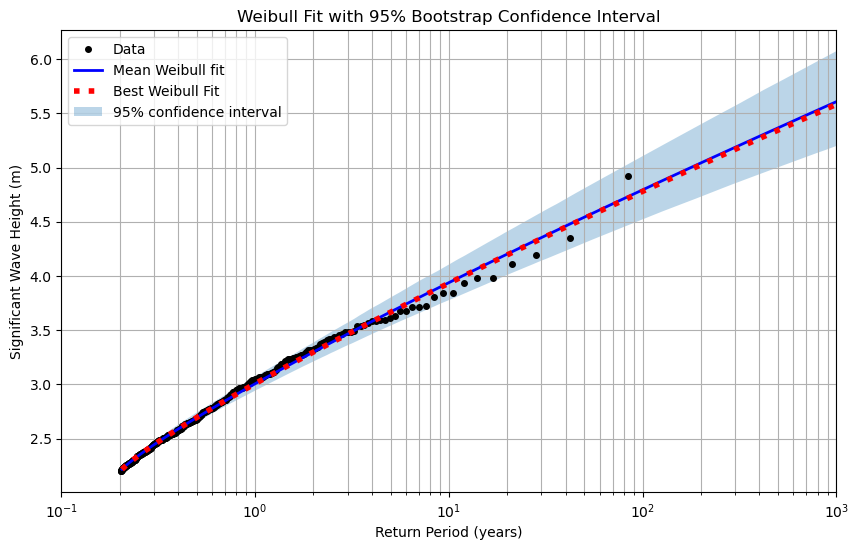

In [ ]:
bootstrap_curves = np.array(bootstrap_curves)

# Mean and 95% confidence interval at each R_fit value
z_mean = np.nanmean(bootstrap_curves, axis=0)
z_lower = np.nanpercentile(bootstrap_curves, 2.5, axis=0)
z_upper = np.nanpercentile(bootstrap_curves, 97.5, axis=0)

plt.figure(figsize=(10, 6))

# Plot empirical data
plt.plot(R, x_sorted, 'ko', markersize=4, label='Data')

# Plot mean Weibull fit
plt.plot(R_fit, z_mean, 'b-', linewidth=2, label='Mean Weibull fit')

# Plot the best fit
plt.plot(R_fit, z_weibull, 'r-', linestyle=':', linewidth=4, label='Best Weibull Fit')

# Plot 95% confidence interval
plt.fill_between(
    R_fit,
    z_lower,
    z_upper,
    alpha=0.3,
    label='95% confidence interval'
)

plt.xlabel('Return Period (years)')
plt.xscale('log')
plt.xlim(0.1, 1000)
plt.ylabel('Significant Wave Height (m)')
plt.title('Weibull Fit with 95% Bootstrap Confidence Interval')
plt.grid(which='both')
plt.legend()
plt.show();

In [ ]:
def get_stats_at_R(target_R_list, R_fit, bootstrap_curves):
    results = []

    for R_target in target_R_list:
        # Find closest index in R_fit
        idx = np.argmin(np.abs(R_fit - R_target))

        values = bootstrap_curves[:, idx]

        # Remove NaNs (important!)
        values = values[~np.isnan(values)]

        std = np.std(values)
        ci_min = np.percentile(values, 2.5)
        ci_max = np.percentile(values, 97.5)

        results.append({
            'Return period': R_target,
            'Std': std,
            'CI_min': ci_min,
            'CI_max': ci_max
        })

    return results

In [ ]:
stats = get_stats_at_R(return_period_list, R_fit, bootstrap_curves)

for s in stats:
    print(f"R = {s['Return period']} years:")
    print(f"  Std      = {s['Std']:.3f}")
    print(f"  CI_min   = {s['CI_min']:.3f}")
    print(f"  CI_max   = {s['CI_max']:.3f}")

R = 1 years:
  Std      = 0.032
  CI_min   = 2.944
  CI_max   = 3.073
R = 10 years:
  Std      = 0.084
  CI_min   = 3.775
  CI_max   = 4.101
R = 50 years:
  Std      = 0.131
  CI_min   = 4.306
  CI_max   = 4.811
R = 100 years:
  Std      = 0.152
  CI_min   = 4.521
  CI_max   = 5.103
R = 500 years:
  Std      = 0.204
  CI_min   = 5.000
  CI_max   = 5.782
R = 1000 years:
  Std      = 0.228
  CI_min   = 5.199
  CI_max   = 6.074


count    416.000000
mean     -10.978768
std        2.504103
min      -17.496628
25%      -12.633743
50%      -11.326599
75%       -9.532619
max       -1.098984
Name: u10, dtype: float64
count    416.000000
mean      -9.230896
std        3.657680
min      -19.852340
25%      -11.842208
50%       -9.676994
75%       -7.054630
max        6.536667
Name: v10, dtype: float64


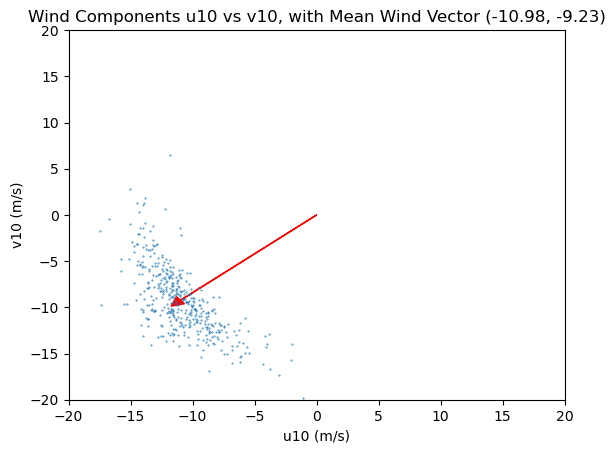

In [ ]:
# Select peaks from wind data
wind_data_peaks = wind_data.iloc[peaks]

# Merge with wave data to get mwd aligned by time
merged = pd.merge(
    wind_data_peaks,
    wave_data_filtered[['valid_time', 'mwd']],
    on='valid_time',
    how='inner'
)

# Filter by direction
wind_data_filtered = merged[
    (merged['mwd'] >= 0) & (merged['mwd'] <= 100)
]

wind_data_filtered.head()
print(wind_data_filtered['u10'].describe())

print(wind_data_filtered['v10'].describe())

plt.plot(wind_data_filtered['u10'], wind_data_filtered['v10'], 'o', markersize=0.4, label='Data Points')
plt.arrow(0 ,0 ,wind_data_filtered['u10'].mean(), wind_data_filtered['v10'].mean(), head_width=1, head_length=1, fc='r', ec='r', label='Mean Wind Vector')
plt.xlabel('u10 (m/s)')
plt.ylabel('v10 (m/s)')

plt.xlim(-20, 20)
plt.ylim(-20, 20)
plt.title(f'Wind Components u10 vs v10, with Mean Wind Vector ({wind_data_filtered["u10"].mean():.2f}, {wind_data_filtered["v10"].mean():.2f})');

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

transect_file = "swan_transect1.tab"

transect = pd.read_csv(
    transect_file,
    comment="%",
    delim_whitespace=True,
    names=["Xp", "Yp", "Hs", "Tp", "Botlev", "Dp"]
)

transect.head()

,Xp,Yp,Hs,Tp,Botlev,Dp
0,778245.0,4933370.0,5.95513,9.0927,23.5655,55.0
1,778170.0,4933364.0,5.95687,9.0927,23.4953,55.0
2,778095.0,4933358.0,5.95886,9.0927,23.4136,55.0
3,778020.0,4933351.0,5.96139,9.0927,23.3298,55.0
4,777945.0,4933344.0,5.96456,9.0927,23.2429,55.0


In [ ]:
dx = np.diff(transect["Xp"], prepend=transect["Xp"].iloc[0])
dy = np.diff(transect["Yp"], prepend=transect["Yp"].iloc[0])

transect["distance_m"] = np.cumsum(np.sqrt(dx**2 + dy**2))
transect["distance_km"] = transect["distance_m"] / 1000

print(transect.columns)

Index(['Xp', 'Yp', 'Hs', 'Tp', 'Botlev', 'Dp', 'distance_m', 'distance_km'], dtype='object')


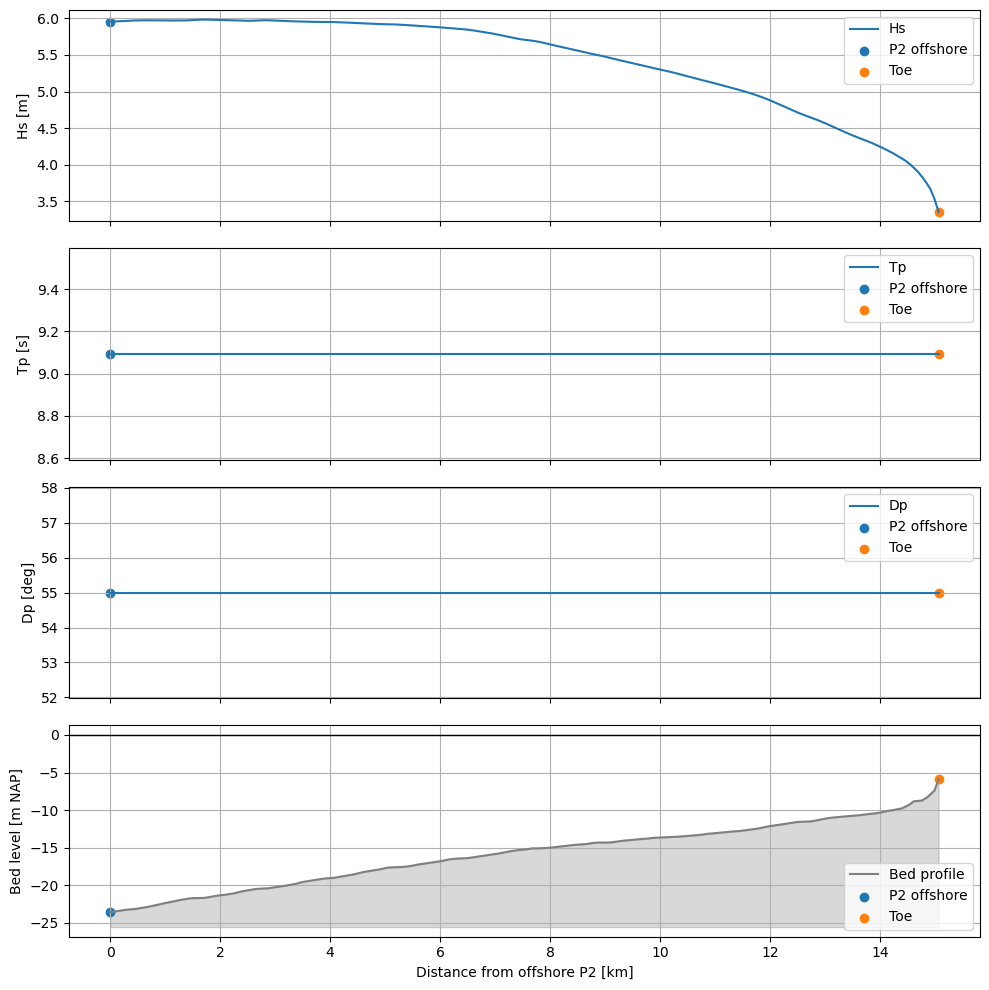

In [ ]:
P2_x = 778245
P2_y = 4933370

toe_x = transect["Xp"].iloc[-1]
toe_y = transect["Yp"].iloc[-1]

toe_distance = transect["distance_km"].iloc[-1]
p2_distance = 0.0

fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

plot_vars = [
    ("Hs", "Hs [m]"),
    ("Tp", "Tp [s]"),
    ("Dp", "Dp [deg]")
]

x = transect["distance_km"]
bed_level = -transect["Botlev"]  # m NAP

for ax, (var, ylabel) in zip(axes[:3], plot_vars):
    ax.plot(x, transect[var], label=var)
    ax.scatter(x.iloc[0], transect[var].iloc[0], label="P2 offshore")
    ax.scatter(x.iloc[-1], transect[var].iloc[-1], label="Toe")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend(loc="best")

# Separate bed profile plot
axes[3].plot(x, bed_level, color="grey", label="Bed profile")
axes[3].fill_between(x, bed_level, bed_level.min() - 2, color="grey", alpha=0.3)

axes[3].scatter(x.iloc[0], bed_level.iloc[0], label="P2 offshore")
axes[3].scatter(x.iloc[-1], bed_level.iloc[-1], label="Toe")

axes[3].axhline(0, color="black", linewidth=1)
axes[3].set_ylabel("Bed level [m NAP]")
axes[3].set_xlabel("Distance from offshore P2 [km]")
axes[3].grid(True)
axes[3].legend(loc="best")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

result_file = "Result.tab"

raw = np.loadtxt(result_file).ravel()

nx = 252
ny = 332
n_points = nx * ny

variables = [
    "Xp", "Yp", "Botlev",
    "Wind_x", "Wind_y",
    "Hs", "Tp", "Tm01", "Tm02", "Tm_10",
    "Dp", "Dir"
]

data = {}

for i, var in enumerate(variables):
    arr = raw[i * n_points : (i + 1) * n_points]
    data[var] = arr.reshape(ny, nx)

X = data["Xp"]
Y = data["Yp"]

# remove SWAN missing values
for key in data:
    data[key] = np.where(data[key] <= -9, np.nan, data[key])
    
def plot_map(var, label):
    plt.figure(figsize=(8, 7))
    
    plt.pcolormesh(X, Y, data[var], shading="auto")
    plt.colorbar(label=label)

    # transect + punten
    plt.plot(transect["Xp"], transect["Yp"], linewidth=1, label="Transect")
    plt.scatter(transect["Xp"].iloc[0], transect["Yp"].iloc[0], label="P2 offshore")
    plt.scatter(transect["Xp"].iloc[-1], transect["Yp"].iloc[-1], label="Toe")

    plt.xlabel("X [m]")
    plt.ylabel("Y [m]")
    plt.axis("equal")
    plt.legend()
    plt.title(label)
    plt.tight_layout()
    plt.show()

C:\Users\Larsk\AppData\Local\Temp\ipykernel_16788\164837848.py:35: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X, Y, data[var], shading="auto")


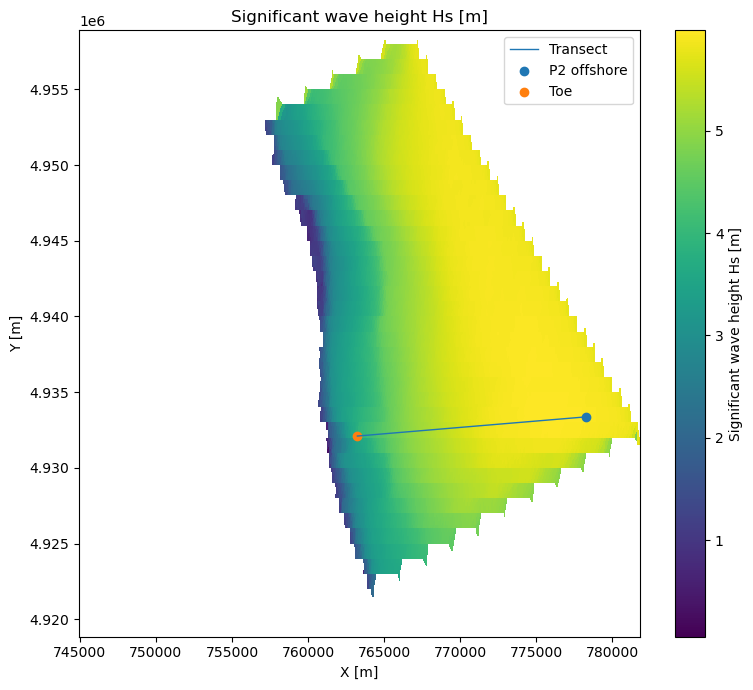

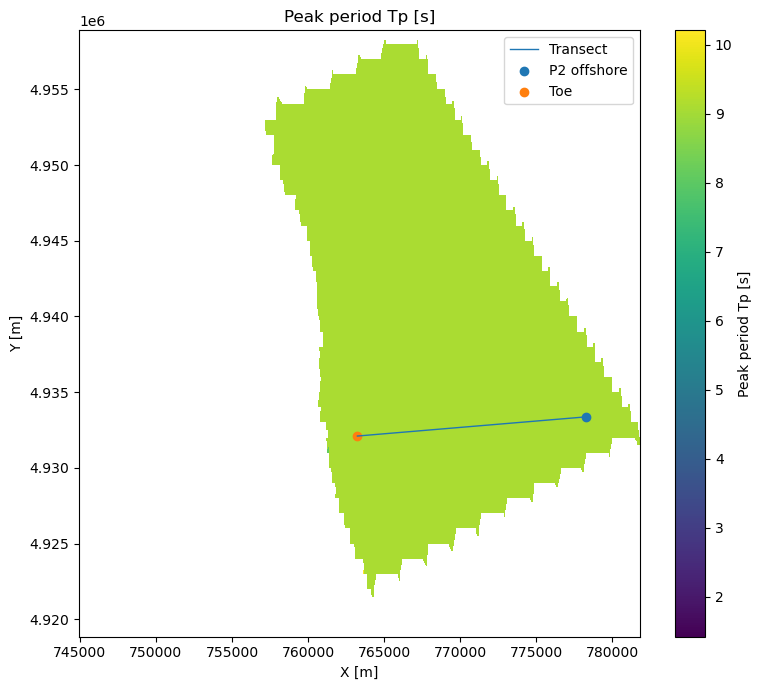

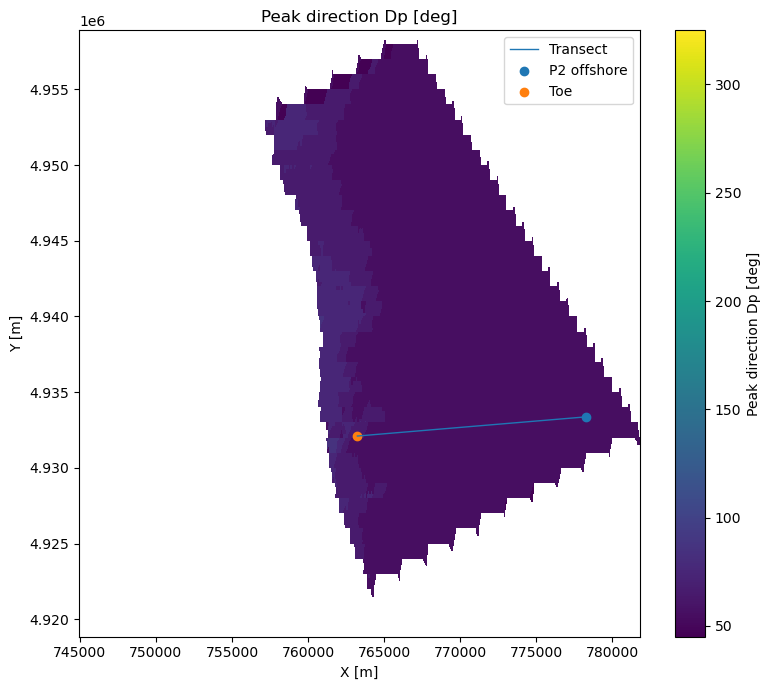

In [ ]:
plot_map("Hs", "Significant wave height Hs [m]")
plot_map("Tp", "Peak period Tp [s]")
plot_map("Dp", "Peak direction Dp [deg]")

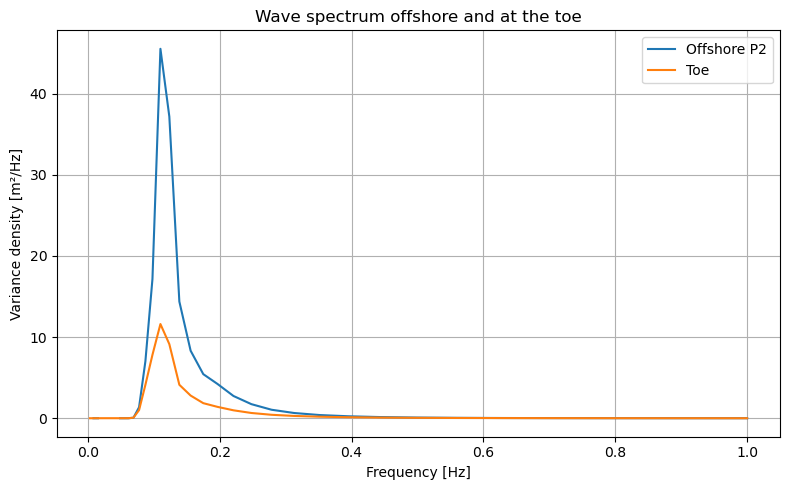

In [ ]:
# Offshore
freq_off = np.loadtxt("swan_specout1.txt", skiprows=8, max_rows=51)
spec_off = np.loadtxt("swan_specout1.txt", skiprows=71, max_rows=51)

# Toe
freq_toe = np.loadtxt("swan_specout2.txt", skiprows=8, max_rows=51)
spec_toe = np.loadtxt("swan_specout2.txt", skiprows=71, max_rows=51)

E_off = spec_off[:, 0]
E_toe = spec_toe[:, 0]

# remove SWAN exception values
E_off[E_off < 0] = np.nan
E_toe[E_toe < 0] = np.nan
plt.figure(figsize=(8,5))

plt.plot(freq_off, E_off, label="Offshore P2")
plt.plot(freq_toe, E_toe, label="Toe")

plt.xlabel("Frequency [Hz]")
plt.ylabel("Variance density [m²/Hz]")
plt.title("Wave spectrum offshore and at the toe")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
toe = transect.iloc[-1]
offshore = transect.iloc[0]

print("Offshore condition:")
print(f"Hs = {offshore['Hs']:.3f} m")
print(f"Tp = {offshore['Tp']:.3f} s")
print(f"Dp = {offshore['Dp']:.3f} deg")

print("\nToe condition:")
print(f"Hs = {toe['Hs']:.3f} m")
print(f"Tp = {toe['Tp']:.3f} s")
print(f"Dp = {toe['Dp']:.3f} deg")
print(f"Depth = {toe['Botlev']:.3f} m")

Hs_toe = toe["Hs"]

ratio_H2_Hs = 1.15
H2 = ratio_H2_Hs * Hs_toe

print(f"H2%/Hs = {ratio_H2_Hs:.2f}")
print(f"H2% = {H2:.3f} m")

Offshore condition:
Hs = 5.955 m
Tp = 9.093 s
Dp = 55.000 deg

Toe condition:
Hs = 3.359 m
Tp = 9.093 s
Dp = 55.000 deg
Depth = 5.903 m
H2%/Hs = 1.15
H2% = 3.863 m
